In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs

In [2]:
centers=[[34.05,-118.24],[40.71,-74.05],[41.87,-87.63]]
x,_ = make_blobs(n_samples=300,centers=centers,cluster_std=0.5,random_state=42)
df = pd.DataFrame(x,columns=['Latitude','Longitude'])
print(df.head())

    Latitude   Longitude
0  33.454348 -117.911723
1  33.777809 -118.184539
2  41.930148  -87.372781
3  40.219246  -73.818948
4  34.079104 -118.811485


In [5]:
dbscan = DBSCAN(eps=0.3,min_samples=5)
df['cluster'] = dbscan.fit_predict(df[['Latitude','Longitude']])
clusters = df[df['cluster']!=-1]
noise = df[df['cluster'] == -1]

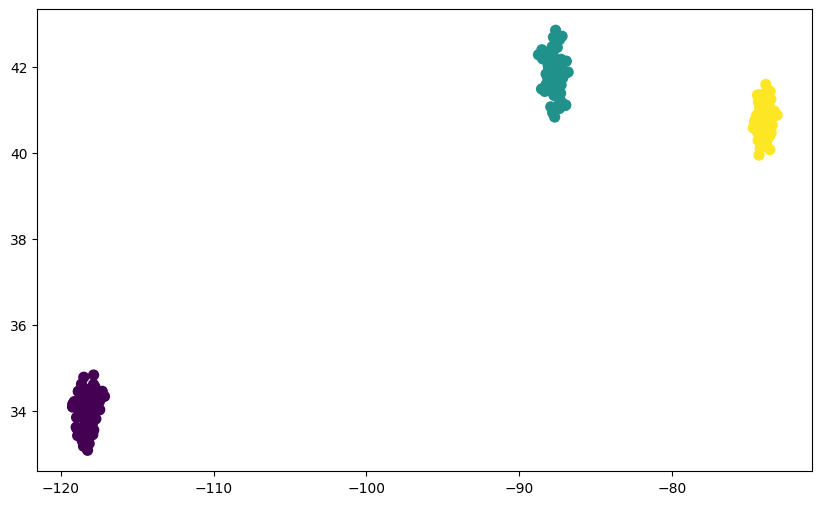

In [6]:
plt.figure(figsize= [10,6])
plt.scatter(clusters['Longitude'],clusters['Latitude'],c=clusters['cluster'],cmap='viridis',label='clusters',s=50)

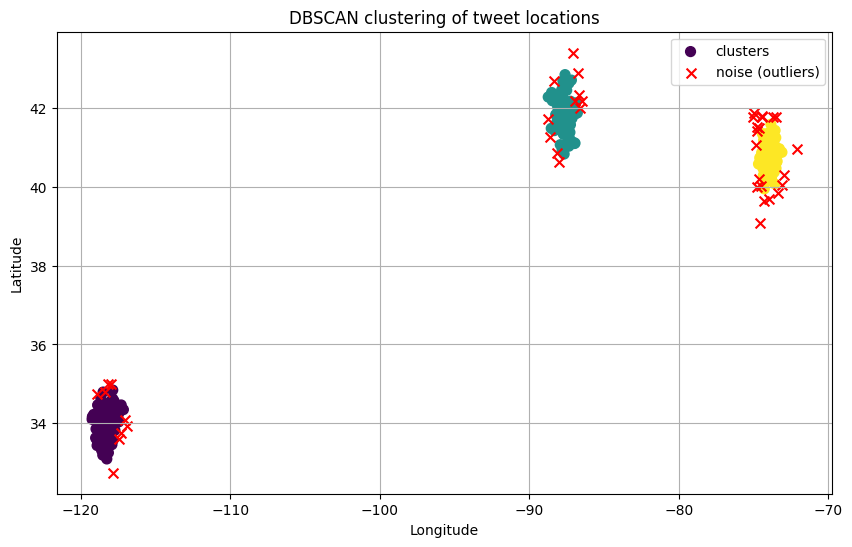

In [10]:
plt.figure(figsize=[10,6])

plt.scatter(
    clusters['Longitude'],
    clusters['Latitude'],
    c=clusters['cluster'],
    cmap='viridis',
    label='clusters',
    s=50
)

plt.scatter(
    noise['Longitude'],
    noise['Latitude'],
    c='red',
    marker='x',
    label='noise (outliers)',
    s=50
)

plt.title("DBSCAN clustering of tweet locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
print(f"Number of clusters found: {len(set(df['cluster']) - ({-1} if -1 in df['cluster'].values else set()))}")
print(f"Number of noise points: {len(noise)}")

Number of clusters found: 3
Number of noise points: 40
